In [1]:
print("Hello, Jupyter!")

Hello, Jupyter!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns



In [3]:
df = pd.read_csv( "C:/Users/User/Downloads/fifa_world_cup_2026_player_performance.csv")


print("Dataset Loaded Successfully")


print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset Loaded Successfully
Rows    : 54,600
Columns : 75


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    
 14  stadium          

In [5]:

categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()


print("Data  Summary")

print(f"Total Records           : {df.shape[0]:,}")
print(f"Total Features          : {df.shape[1]}")
print(f"Categorical Features    : {len(categorical_cols)}")
print(f"Numerical Features      : {len(numerical_cols)}")
print(f"Missing Values          : {df.isnull().sum().sum()}")
print(f"Duplicate Records       : {df.duplicated().sum()}")

Data  Summary
Total Records           : 54,600
Total Features          : 75
Categorical Features    : 14
Numerical Features      : 61
Missing Values          : 0
Duplicate Records       : 0


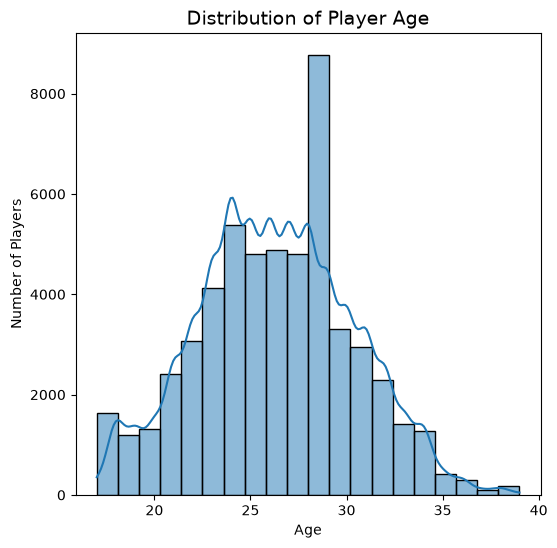

In [6]:
plt.figure(figsize=(6,6))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Distribution of Player Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()

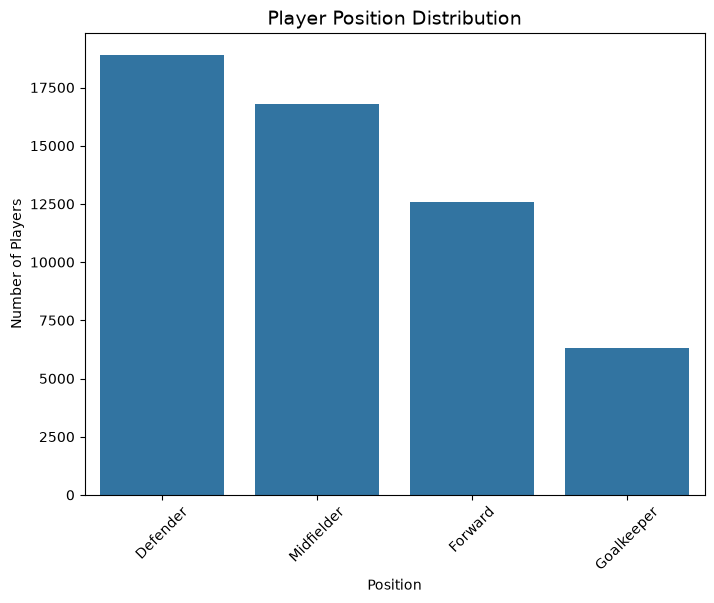

In [7]:
plt.figure(figsize=(8,6))

position_counts = df["position"].value_counts()

sns.barplot(
    x=position_counts.index,
    y=position_counts.values
)

plt.title("Player Position Distribution", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)

plt.show()

In [8]:
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode().iloc[0]
    skew_val = df[col].skew()

    print(f"Mean of {col}: {mean_val}")
    print(f"Median of {col}: {median_val}")
    print(f"Mode of {col}: {mode_val}")
    print(f"Skew of {col}: {skew_val}")

    if np.isclose(mean_val, median_val, atol=0.1):
        print("Data is approximately symmetric")
    elif skew_val > 0:
        print("Data is right-skewed (positively skewed)")
    else:
        print("Data is left-skewed (negatively skewed)")

    print("-" * 70)

Mean of age: 26.296483516483516
Median of age: 26.0
Mode of age: 24
Skew of age: 0.09924963983161143
Data is right-skewed (positively skewed)
----------------------------------------------------------------------
Mean of jersey_number: 13.5
Median of jersey_number: 13.5
Mode of jersey_number: 1
Skew of jersey_number: 0.0
Data is approximately symmetric
----------------------------------------------------------------------
Mean of height_cm: 181.65434065934065
Median of height_cm: 182.0
Mode of height_cm: 183
Skew of height_cm: -0.18455778077198856
Data is left-skewed (negatively skewed)
----------------------------------------------------------------------
Mean of weight_kg: 75.75485347985348
Median of weight_kg: 76.0
Mode of weight_kg: 76
Skew of weight_kg: -0.08951867556756829
Data is left-skewed (negatively skewed)
----------------------------------------------------------------------
Mean of market_value_eur: 20084451.764725275
Median of market_value_eur: 10271107.0
Mode of market_

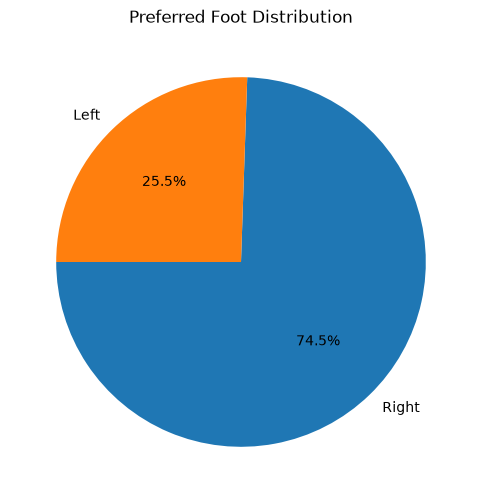

In [9]:
plt.figure(figsize=(6,6))

df["preferred_foot"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=180
)

plt.ylabel("")
plt.title("Preferred Foot Distribution")

plt.show()

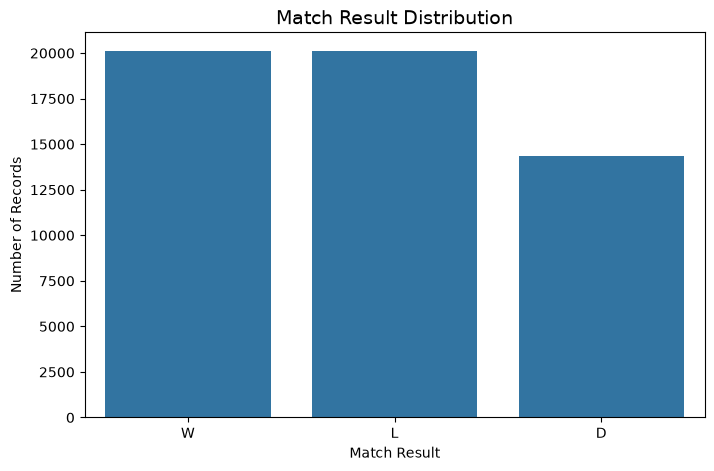

In [10]:
plt.figure(figsize=(8, 5))

match_result = df["match_result"].value_counts()

sns.barplot(
    x=match_result.index,
    y=match_result.values
)

plt.title("Match Result Distribution", fontsize=14)
plt.xlabel("Match Result")
plt.ylabel("Number of Records")

plt.show()


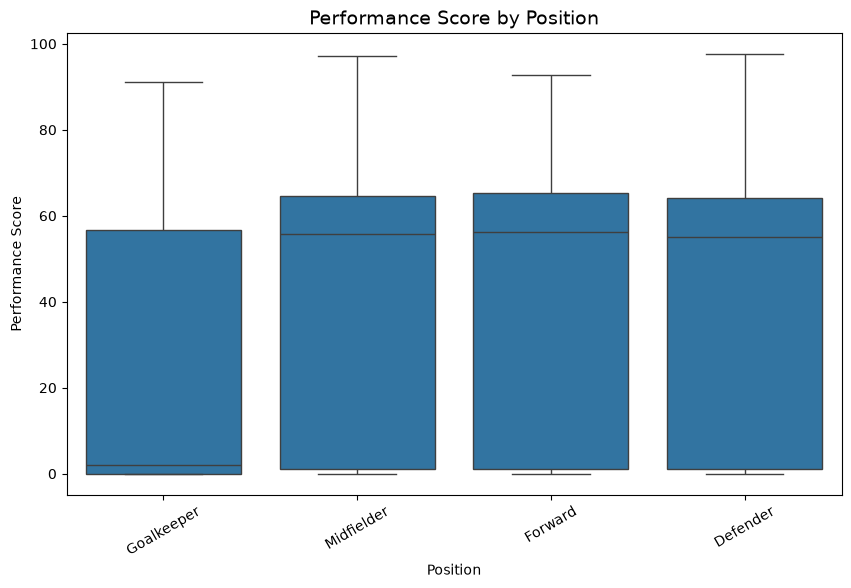

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="position",
    y="performance_score"
)

plt.title("Performance Score by Position", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Performance Score")

plt.xticks(rotation=30)

plt.show()

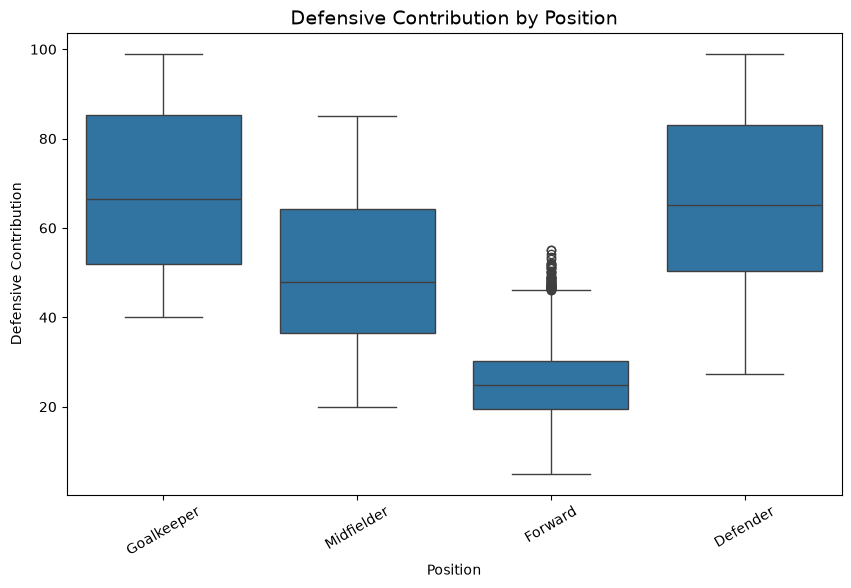

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="position",
    y="defensive_contribution"
)

plt.title("Defensive Contribution by Position", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Defensive Contribution")

plt.xticks(rotation=30)

plt.show()

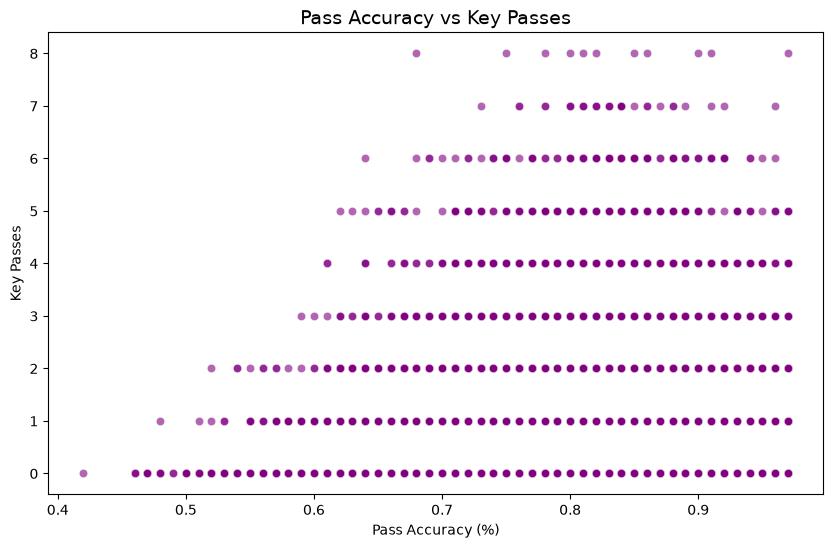

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="pass_accuracy",
    y="key_passes",
    alpha=0.6,
    color= "purple"
)

plt.title("Pass Accuracy vs Key Passes", fontsize=14)
plt.xlabel("Pass Accuracy (%)")
plt.ylabel("Key Passes")

plt.show()

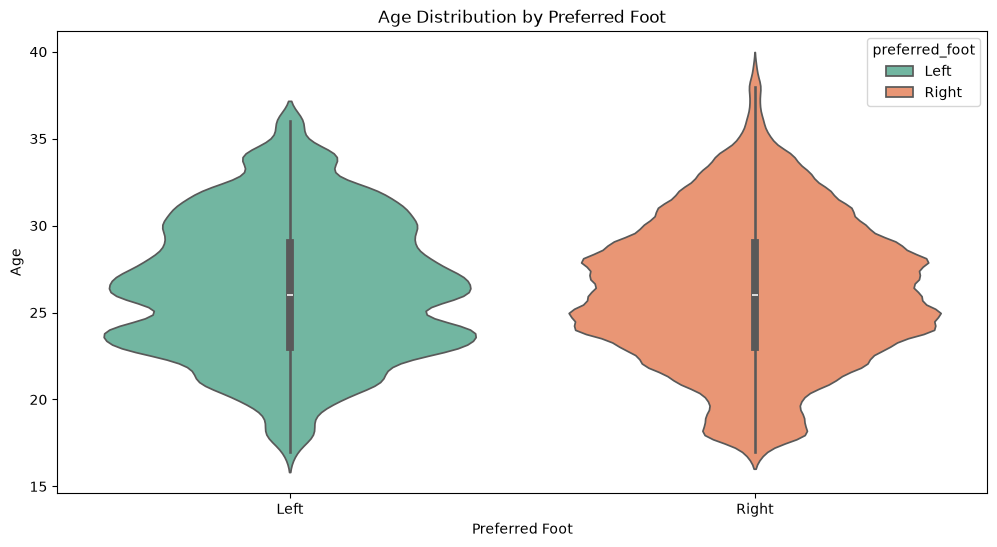

In [14]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x="preferred_foot",
    y="age",
    hue="preferred_foot",
    palette="Set2",
    legend=True,
    inner="box"
)

plt.title("Age Distribution by Preferred Foot")
plt.xlabel("Preferred Foot")
plt.ylabel("Age")

plt.show()

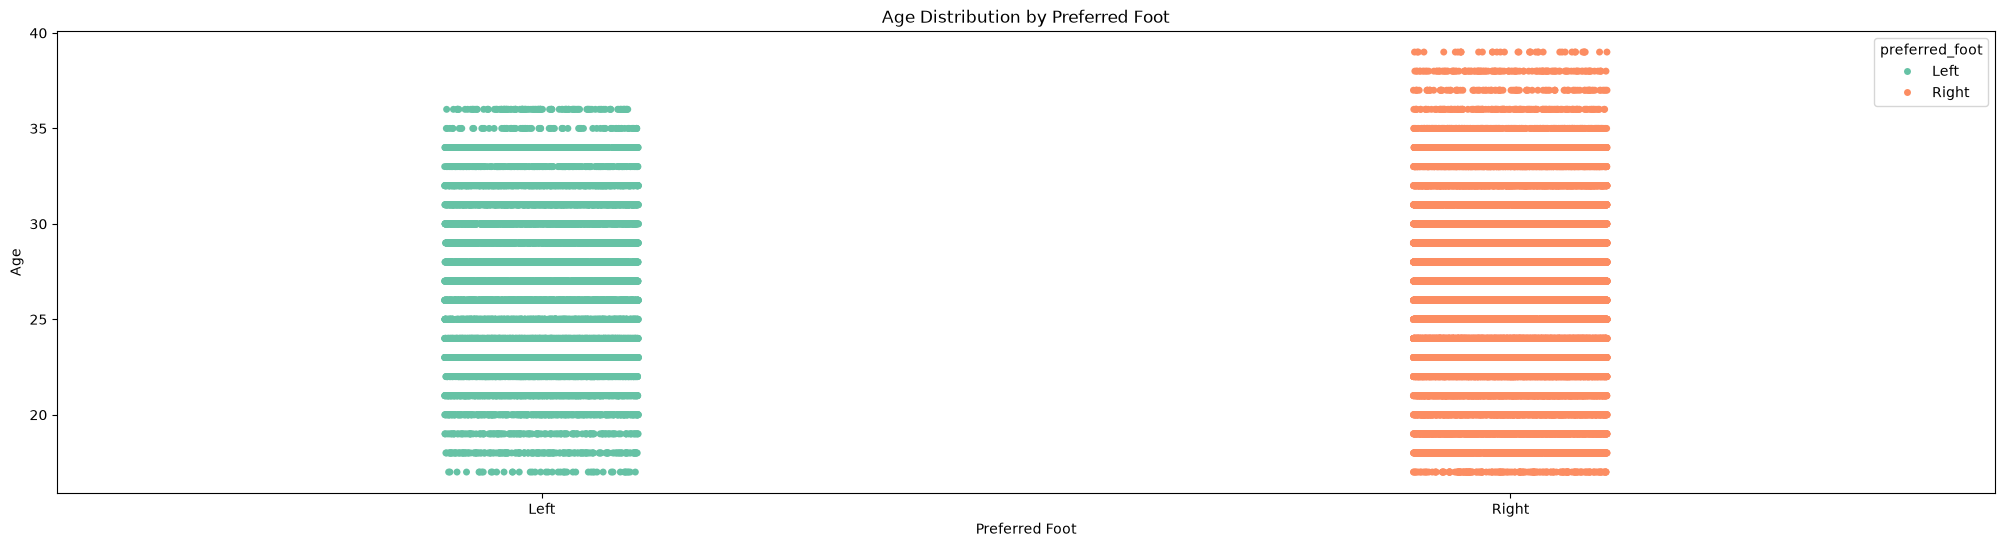

In [15]:
plt.figure(figsize=(25, 6))

sns.stripplot(
    data=df,
    x="preferred_foot",
    y="age",
    hue="preferred_foot",
    palette="Set2",
    legend=True,
    jitter=True,
    alpha=1
)

plt.title("Age Distribution by Preferred Foot")
plt.xlabel("Preferred Foot")
plt.ylabel("Age")

plt.show()

In [16]:

# plt.figure(figsize=(10,6))
# sns.swarmplot(
#     data=df,
#     x="position",
#     y="tournament_rating",
#     hue="position",
#     palette="Set2",
#     legend=True,
#     size=3
# )

# plt.title("Tournament Rating by Player Position")
# plt.xlabel("Position")
# plt.ylabel("Tournament Rating")
# plt.show()

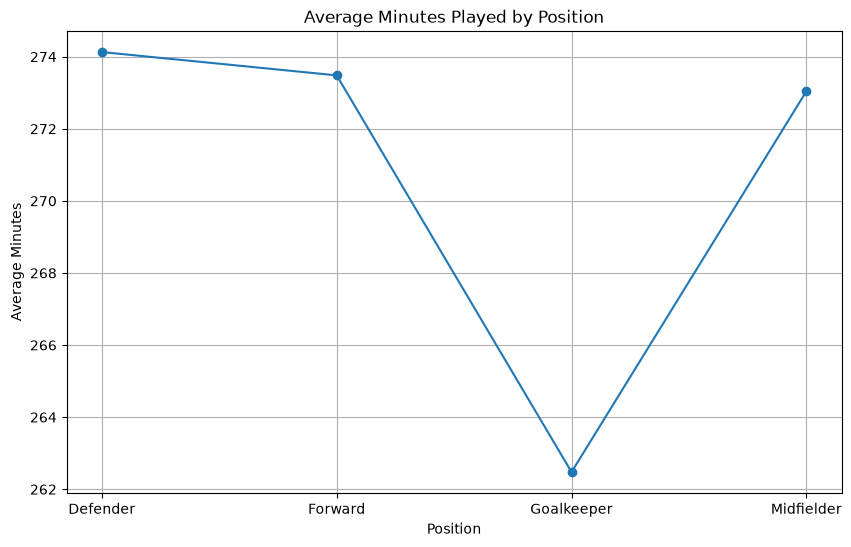

In [17]:
avg_minutes = df.groupby("position")["total_minutes_tournament"].mean()

plt.figure(figsize=(10,6))

plt.plot(
    avg_minutes.index,
    avg_minutes.values,
    marker='o'
)

plt.title("Average Minutes Played by Position")
plt.xlabel("Position")
plt.ylabel("Average Minutes")

plt.grid(True)

plt.show()

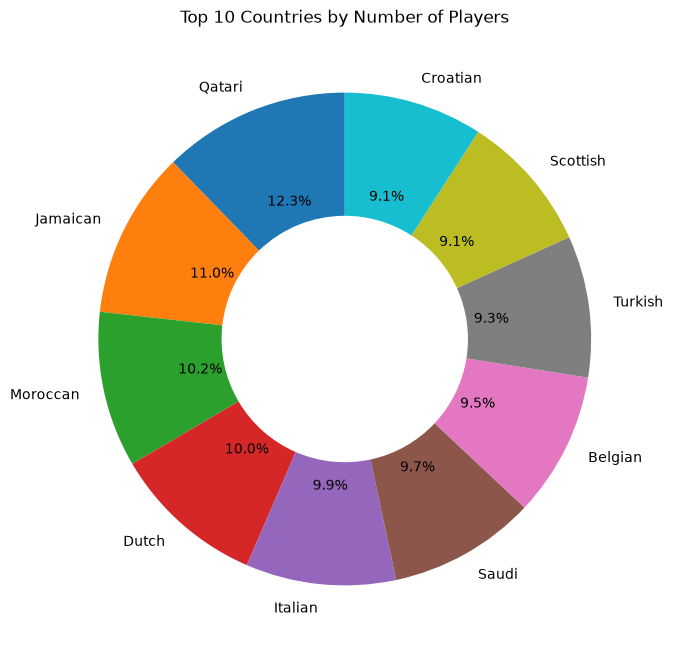

In [18]:


country_counts = df["nationality"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    country_counts,
    labels=country_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.5)
)

plt.title("Top 10 Countries by Number of Players")

plt.show()

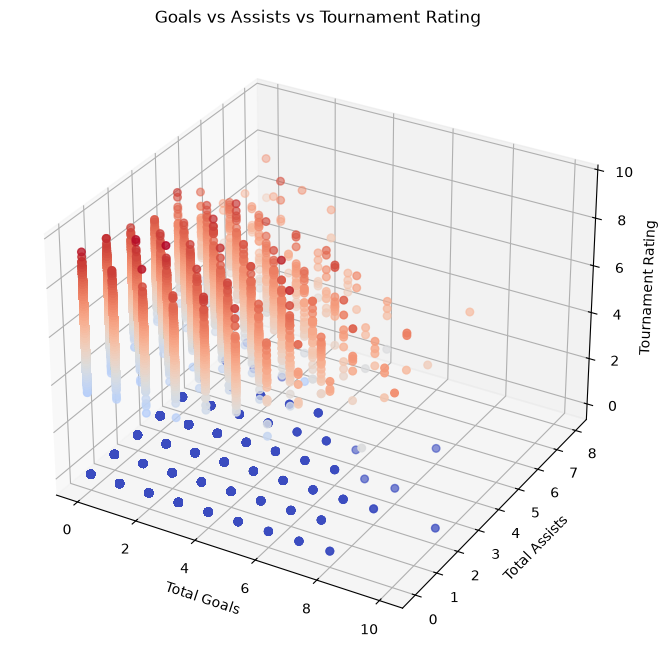

In [19]:


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["total_goals_tournament"],
    df["total_assists_tournament"],
    df["tournament_rating"],
    c=df["tournament_rating"],
    cmap="coolwarm",
    s=30
)

ax.set_title("Goals vs Assists vs Tournament Rating")
ax.set_xlabel("Total Goals")
ax.set_ylabel("Total Assists")
ax.set_zlabel("Tournament Rating")

plt.show()

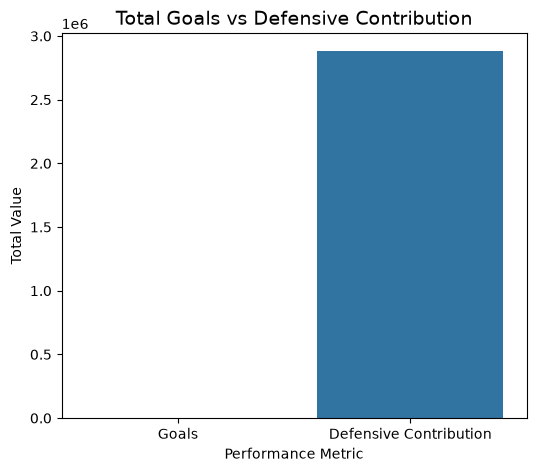

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = {
    "Goals": df["goals"].sum(),
    "Defensive Contribution": df["defensive_contribution"].sum()
}

plt.figure(figsize=(6,5))

sns.barplot(
    x=list(metrics.keys()),
    y=list(metrics.values())
)

plt.title("Total Goals vs Defensive Contribution", fontsize=14)
plt.xlabel("Performance Metric")
plt.ylabel("Total Value")

plt.show()

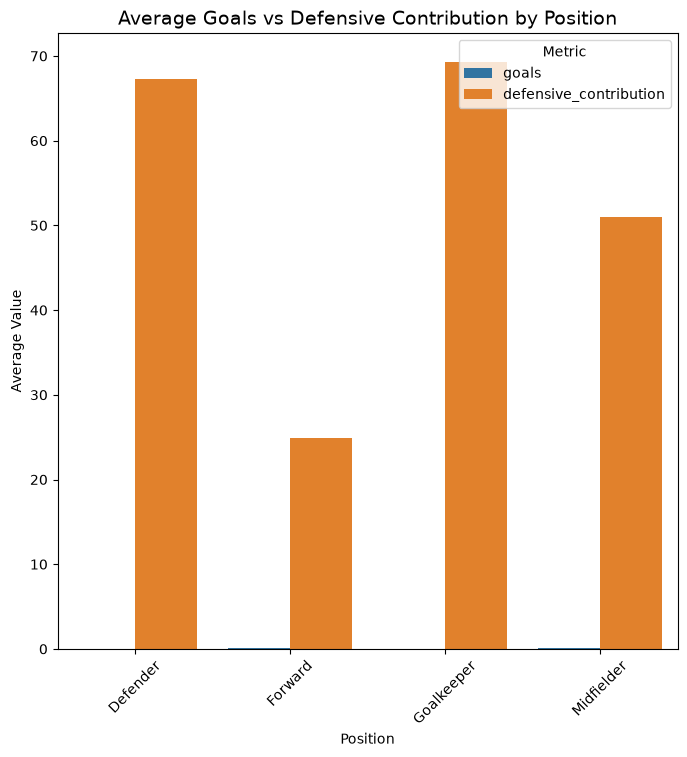

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

position_stats = df.groupby("position")[["goals", "defensive_contribution"]].mean().reset_index()

plot_data = position_stats.melt(
    id_vars="position",
    value_vars=["goals", "defensive_contribution"],
    var_name="Metric",
    value_name="Average Value"
)

plt.figure(figsize=(8,8))

sns.barplot(
    data=plot_data,
    x="position",
    y="Average Value",
    hue="Metric"
)

plt.title("Average Goals vs Defensive Contribution by Position", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Average Value")
plt.xticks(rotation=45)

plt.show()

In [ ]:
top_player = df.loc[df["total_goals_tournament"].idxmax()]

print(top_player[["player_name","team", "nationality", "total_goals_tournament"]])

player_name               Stuart McTominay
nationality                       Scottish
total_goals_tournament                  10
Name: 4303, dtype: object
